In [1]:
import pandas as pd
import numpy as np
from IPython import display
from pyecharts.charts import Bar, Page, Pie, WordCloud
from pyecharts import options as opts
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置 matplotlib 的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像时符号'-'显示为方块的问题

In [2]:
data=pd.read_csv('../data/job.csv')
data.head()

,职位名称,薪资范围,地点,工作经验,学历要求,岗位标签,公司名称,公司类型,公司规模,city
0,销售数据分析,1.2万-1.8万,上海,3-5年,本科,"['IT/互联网', 'Java', 'Python', 'SPSS', 'SAS', 'S...",云竞(上海)电子科技有限公司,民营,500-999人,上海
1,金融数据分析师,1.6万-1.8万,上海-黄浦,3-5年,本科,"['银行数据分析', '投融资数据分析', 'SQL', 'Python', '决策树']",北京戌华防务技术有限公司,民营,100-299人,上海
2,酒店财务数据分析,1.2万-1.5万,上海,3-5年,本科,['Power BI'],上海锦江国际酒店股份有限公司第一分公司,国企,100-299人,上海
3,数据分析经理,1.5万-1.8万,上海-徐汇,5-10年,本科,"['SQL', 'R', '数学/统计学专业', '线下零售', '餐饮业']",达美乐比萨,外商独资,500-999人,上海
4,IT校招-数据分析师(J13446),1万-2万,上海-青浦,不限,本科,"['Python', 'Tableau', '运营数据分析']",中通快递,股份制企业,10000人以上,上海


In [3]:
data.shape

(6685, 10)

In [4]:
#检查缺失值
missing_values = data.isnull().sum()
data = data.dropna(axis=0)
#检查重复值
duplicate_rows = data.duplicated().sum()
data = data.drop_duplicates()
data.shape

(6611, 10)

In [5]:
def convert_salary_range(salary_str):
    pattern = re.compile(r'([\d.]+)([千万])?-([\d.]+)([千万])?')
    match = pattern.match(salary_str)

    # 如果匹配失败，返回 NaN 值
    if match is None:
        return pd.Series([np.nan, np.nan], index=['最低薪资', '最高薪资'])

    # 提取匹配的组
    lower, lower_unit, upper, upper_unit = match.groups()

    # 转换为数值（单位：元）
    # 有"千"乘1000，有"万"乘10000，无单位则已经是元
    lower_val = float(lower)
    upper_val = float(upper)
    if lower_unit == '千':
        lower = lower_val * 1000
    elif lower_unit == '万':
        lower = lower_val * 10000
    else:
        lower = lower_val  # 已经是元，不要乘

    if upper_unit == '千':
        upper = upper_val * 1000
    elif upper_unit == '万':
        upper = upper_val * 10000
    else:
        upper = upper_val  # 已经是元，不要乘

    return pd.Series([lower, upper], index=['最低薪资', '最高薪资'])

data_salary_bounds = data["薪资范围"].apply(convert_salary_range)
data = pd.concat([data, data_salary_bounds], axis=1)

In [6]:
data.head()

,职位名称,薪资范围,地点,工作经验,学历要求,岗位标签,公司名称,公司类型,公司规模,city,最低薪资,最高薪资
0,销售数据分析,1.2万-1.8万,上海,3-5年,本科,"['IT/互联网', 'Java', 'Python', 'SPSS', 'SAS', 'S...",云竞(上海)电子科技有限公司,民营,500-999人,上海,12000.0,18000.0
1,金融数据分析师,1.6万-1.8万,上海-黄浦,3-5年,本科,"['银行数据分析', '投融资数据分析', 'SQL', 'Python', '决策树']",北京戌华防务技术有限公司,民营,100-299人,上海,16000.0,18000.0
2,酒店财务数据分析,1.2万-1.5万,上海,3-5年,本科,['Power BI'],上海锦江国际酒店股份有限公司第一分公司,国企,100-299人,上海,12000.0,15000.0
3,数据分析经理,1.5万-1.8万,上海-徐汇,5-10年,本科,"['SQL', 'R', '数学/统计学专业', '线下零售', '餐饮业']",达美乐比萨,外商独资,500-999人,上海,15000.0,18000.0
4,IT校招-数据分析师(J13446),1万-2万,上海-青浦,不限,本科,"['Python', 'Tableau', '运营数据分析']",中通快递,股份制企业,10000人以上,上海,10000.0,20000.0


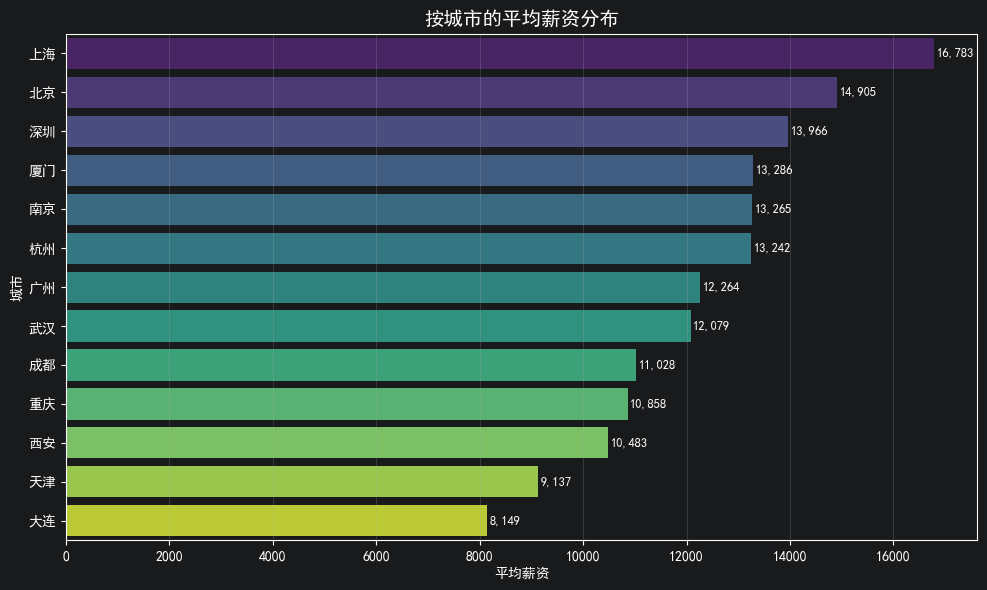

In [9]:
# 计算平均薪资列
data['平均薪资'] = (data['最低薪资'] + data['最高薪资']) / 2

# 计算每个城市的平均薪资
average_salary_by_city = data.groupby('city')['平均薪资'].mean().sort_values(ascending=False)

import os

# 创建 output 目录
os.makedirs('../output', exist_ok=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=average_salary_by_city.values, y=average_salary_by_city.index,
                 hue=average_salary_by_city.index, palette="viridis", legend=False)
# 添加数值标签
for i, v in enumerate(average_salary_by_city.values):
    ax.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)
plt.xlabel('平均薪资')
plt.ylabel('城市')
plt.title('按城市的平均薪资分布', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/按城市平均薪资分布.png', dpi=150)
plt.close()

C:\Users\jlhan\AppData\Local\Temp\ipykernel_12964\3013268137.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y='平均薪资', data=data, order=city_order, palette="viridis")


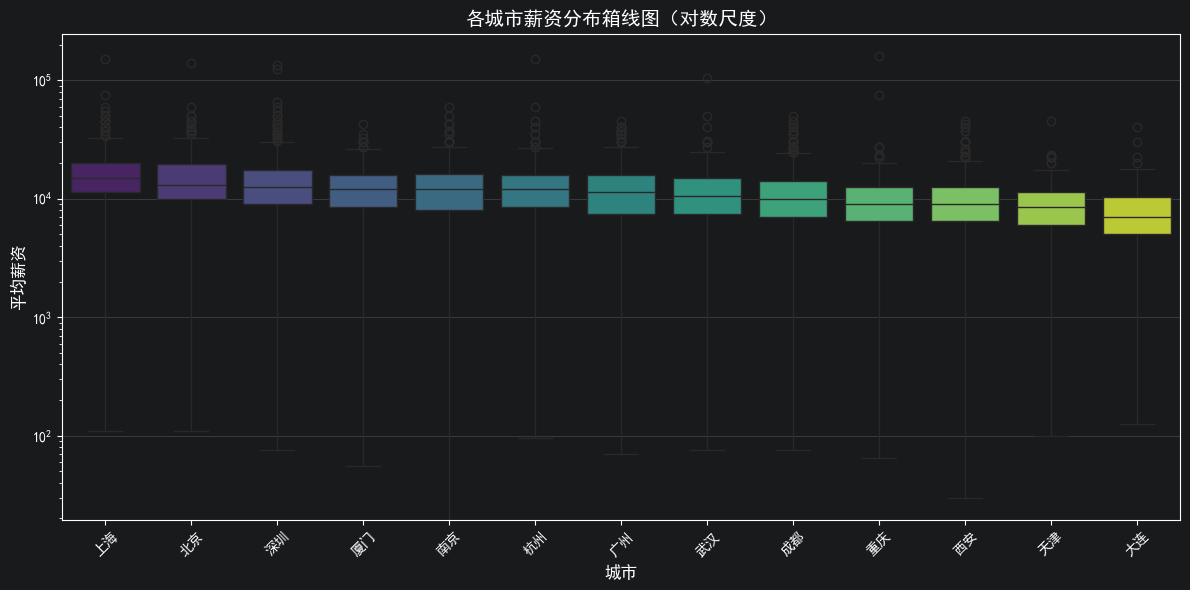

In [11]:
city_order = data.groupby('city')['平均薪资'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='city', y='平均薪资', data=data, order=city_order, palette="viridis")
plt.yscale('log')
plt.xticks(rotation=45)
plt.xlabel('城市', fontsize=12)
plt.ylabel('平均薪资', fontsize=12)
plt.title('各城市薪资分布箱线图（对数尺度）', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/各城市薪资分布箱线图.png', dpi=150)
plt.close()

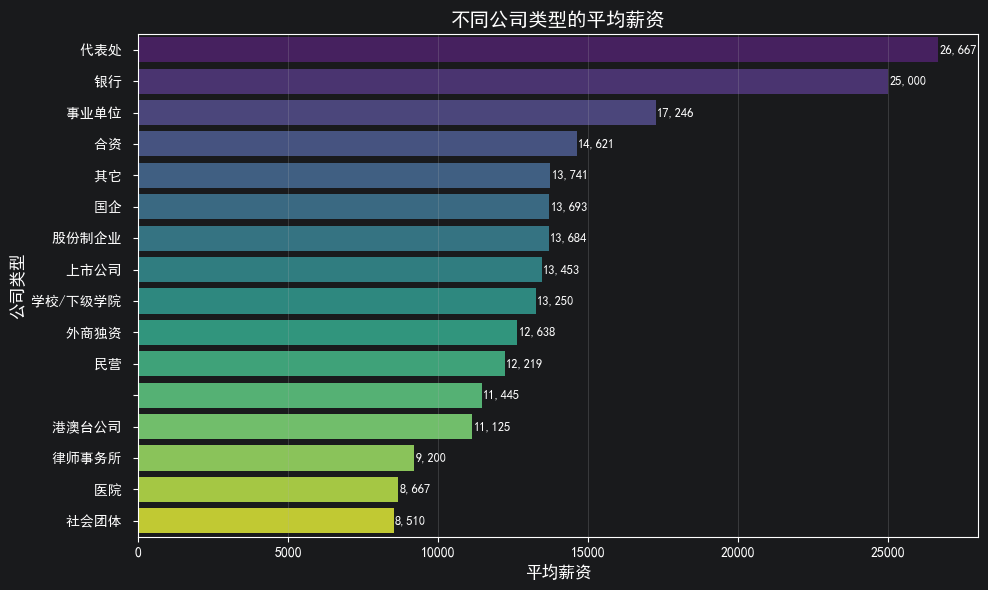

In [13]:
average_salary_by_industry = data.groupby('公司类型')['平均薪资'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=average_salary_by_industry.values, y=average_salary_by_industry.index,
                 hue=average_salary_by_industry.index, palette="viridis", legend=False)
for i, v in enumerate(average_salary_by_industry.values):
    ax.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)
plt.xlabel('平均薪资', fontsize=12)
plt.ylabel('公司类型', fontsize=12)
plt.title('不同公司类型的平均薪资', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/不同公司类型平均薪资.png', dpi=150)
plt.close()

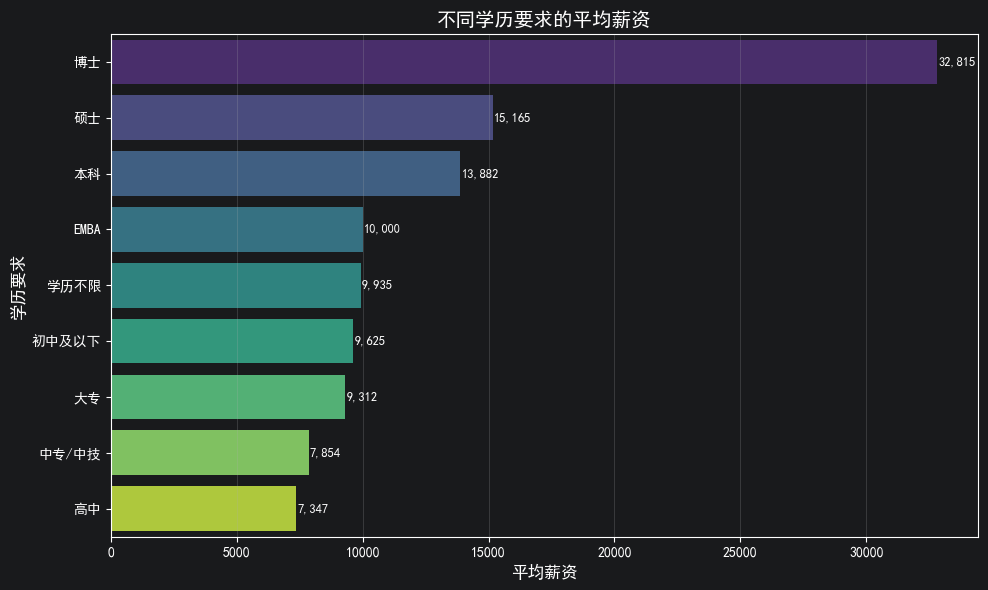

In [14]:
average_salary_by_education = data.groupby('学历要求')['平均薪资'].mean().sort_values(ascending=False)

# 注意：必须按排序后的顺序指定 y 轴类别顺序，否则 seaborn 会按字母排序
education_order = average_salary_by_education.index.tolist()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=average_salary_by_education.values, y=average_salary_by_education.index,
                 hue=average_salary_by_education.index, order=education_order, palette="viridis", legend=False)
for i, v in enumerate(average_salary_by_education.values):
    ax.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)
plt.xlabel('平均薪资', fontsize=12)
plt.ylabel('学历要求', fontsize=12)
plt.title('不同学历要求的平均薪资', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/学历与薪资关系分析.png', dpi=150)
plt.close()

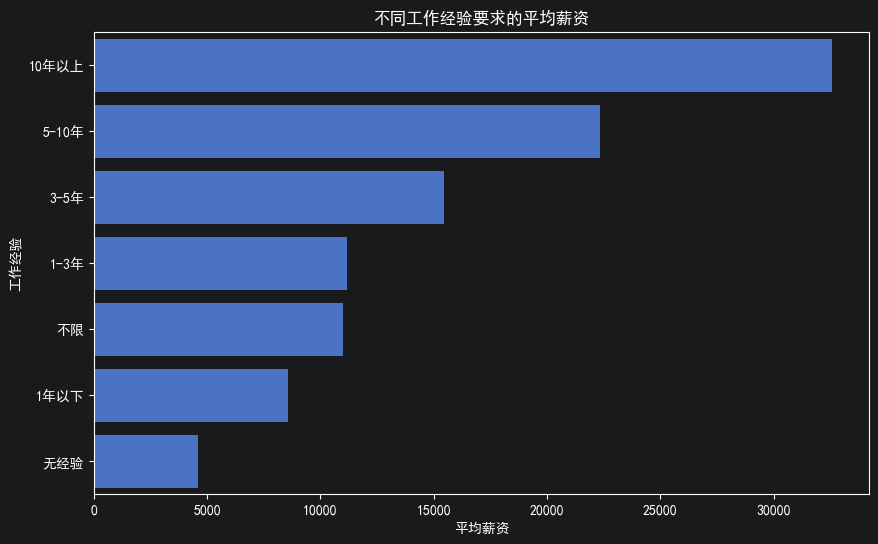

In [15]:
average_salary_by_experience = data.groupby('工作经验')['平均薪资'].mean().sort_values(ascending=False)
# 使用 seaborn 创建条形图
plt.figure(figsize=(10, 6))  # 设置图表大小
sns.barplot(x=average_salary_by_experience.values, y=average_salary_by_experience.index)
plt.xlabel('平均薪资')
plt.title('不同工作经验要求的平均薪资')
plt.show()